In [1]:
#importing required python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.utils.np_utils import to_categorical
import os
#loading resnet and attention model
from keras.applications.resnet50 import ResNet50, preprocess_input
from Attention import attention
from keras.preprocessing import image
from keras import layers, models, Input, Model
from keras.models import Sequential
from keras.layers import  MaxPooling2D, Conv2D, Flatten, Dense, Input, Concatenate, Dropout, RepeatVector
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
import pickle
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [35]:
#loading and displaying HAM 10000 metadata values
dataset = pd.read_csv("Dataset/HAM/HAM10000_metadata.csv")
dataset

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
...,...,...,...,...,...,...,...
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face


In [36]:
#applying onehot encoding on categorical data
image_id = dataset['image_id'].ravel()
ham_labels = np.unique(dataset['dx']).ravel()
dataset.drop(['lesion_id','image_id'], axis = 1,inplace=True)
label_encoder = []
columns = dataset.columns
types = dataset.dtypes.values
for j in range(len(types)):
    name = types[j]
    if name == 'object': #finding column with object type
        le = LabelEncoder()
        dataset[columns[j]] = pd.Series(le.fit_transform(dataset[columns[j]].astype(str)))#encode all str columns to numeric
        label_encoder.append([columns[j], le])
dataset.fillna(dataset.mean(), inplace = True)
dataset

,dx,dx_type,age,sex,localization
0,2,3,80.0,1,11
1,2,3,80.0,1,11
2,2,3,80.0,1,11
3,2,3,80.0,1,11
4,2,3,75.0,1,4
...,...,...,...,...,...
10010,0,3,40.0,1,0
10011,0,3,40.0,1,0
10012,0,3,40.0,1,0
10013,0,3,80.0,1,5


In [37]:
#normalizing metadata features
Y = dataset['dx'].ravel()
dataset.drop(['dx'], axis = 1,inplace=True)
X = dataset.values
scaler = StandardScaler()
X = scaler.fit_transform(X)
print("Normalized features = "+str(X))

Normalized features = [[ 0.83550694  1.6629526   0.88232102  0.84787086]
 [ 0.83550694  1.6629526   0.88232102  0.84787086]
 [ 0.83550694  1.6629526   0.88232102  0.84787086]
 ...
 [ 0.83550694 -0.70119644  0.88232102 -1.46925581]
 [ 0.83550694  1.6629526   0.88232102 -0.41601642]
 [ 0.83550694  1.07191534 -1.08351769 -1.04796005]]


In [38]:
#loading resnet50 model for features extraction
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("Resnet50 model loaded")

Resnet50 model loaded


In [39]:
#read, process and extract features from images
if os.path.exists("model/ham.npy"):
    img = np.load("model/ham.npy")    
else:
    img = []
    for i in range(len(image_id)):
        path = None
        if os.path.exists("Dataset/HAM/HAM10000_images_part_1/"+image_id[i]+".jpg"):
            path = "Dataset/HAM/HAM10000_images_part_1/"+image_id[i]+".jpg"
        else:
            path = "Dataset/HAM/HAM10000_images_part_2/"+image_id[i]+".jpg"
        x = image.load_img(path, target_size=(64, 64))#loading image
        x = image.img_to_array(x)
        x = np.expand_dims(x, axis=0) 
        x = preprocess_input(x)#process image as per resnet format
        img.append(x[0])
    img = np.asarray(img)
    img = resnet_model.predict(img)#apply resnet to extract features
    img = np.asarray(img)
    np.save("model/ham",img)
print("Total features extracted from each image by Resnet50 = "+str(img.shape[1]))
img = np.reshape(img, (img.shape[0], 64, 32, 1))   
print("Total HAM images available in dataset = "+str(img.shape[0]))

Total features extracted from each image by Resnet50 = 2048
Total HAM images available in dataset = 10015


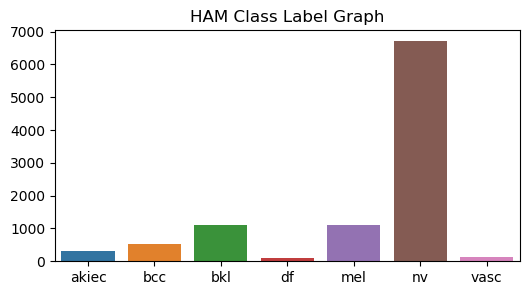

In [40]:
#graphs of different class labels available in dataset
unique, count = np.unique(Y,return_counts=True)
plt.figure(figsize=(6, 3))
sns.barplot(x=ham_labels,y=count)
plt.title("HAM Class Label Graph")
plt.show() 

In [41]:
#shuffling images and metadata features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices] #X contains metadata
Y = Y[indices] #Y contains labels
img = img[indices] #img contains image features
Y = to_categorical(Y)
print("Features shuffling process completed")

Features shuffling process completed


In [42]:
#split dataset into train, test and validation for only images
X_train, X_test, y_train, y_test = train_test_split(img, Y, test_size=0.1, random_state=42, stratify=Y) 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 

#split image and metadata features into train and test
X_img_train, X_img_test, X_meta_train, X_meta_test, y_trains, y_tests = train_test_split(img, X, Y, test_size=0.1, random_state=42, stratify=Y)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = train_test_split(X_img_train, X_meta_train, y_trains, test_size=0.2, random_state=42, stratify=y_trains)

print("Dataset Split Details")
print("70% dataset features used to train algorithms : "+str(X_train.shape[0]))
print("10% dataset features used to test algorithms : "+str(X_test.shape[0]))
print("20% dataset features used to validate algorithms : "+str(X_val.shape[0]))

Dataset Split Details
70% dataset features used to train algorithms : 7210
10% dataset features used to test algorithms : 1002
20% dataset features used to validate algorithms : 1803


In [43]:
#defining augmentation model
aug = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                         horizontal_flip=True, fill_mode="nearest")

In [44]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict, prob):
    a = round(accuracy_score(testY,predict), 2)
    auc_value = roc_auc_score(testY,prob,multi_class='ovr')
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" AUC       : "+str(auc_value))
    print(classification_report(testY,predict, target_names=ham_labels))
    
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = ham_labels, yticklabels = ham_labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(ham_labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 
    color = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan', 'orange']
    for i in range(len(ham_labels)):   
        fpr, tpr, thresh = roc_curve(testY, prob[:,i], pos_label=i)
        axs[1].plot(fpr, tpr, linestyle='--',color=color[i], label=ham_labels[i])
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    axs[1].legend()
    plt.show()

Image Only Model Accuracy  : 0.79
Image Only Model AUC       : 0.9476086616822493
              precision    recall  f1-score   support

       akiec       0.61      0.37      0.46        59
         bcc       0.62      0.68      0.65        93
         bkl       0.61      0.43      0.51       198
          df       1.00      0.25      0.40        20
         mel       0.65      0.28      0.39       200
          nv       0.83      0.98      0.90      1207
        vasc       0.93      0.50      0.65        26

    accuracy                           0.79      1803
   macro avg       0.75      0.50      0.56      1803
weighted avg       0.77      0.79      0.76      1803



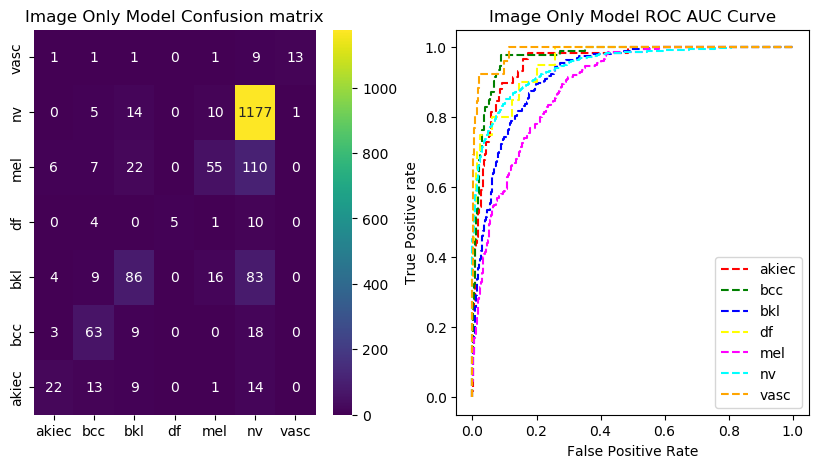

In [45]:
#training deep learning image only model
img_model = Sequential()
img_model.add(Conv2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Conv2D(64, (3, 3), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Flatten())
img_model.add(Dense(units = 128, activation = 'relu'))
img_model.add(Dropout(0.5))
img_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
img_model.compile(optimizer = "adam", loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/img_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/img_weights.hdf5', verbose = 1, save_best_only = True)
    hist = img_model.fit(X_train, y_train, batch_size = 32, epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/img_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    img_model.load_weights("model/img_weights.hdf5")
#perform prediction on validation data    
prob = img_model.predict(X_val)
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_val, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image Only Model", y_test1, predict, prob)

Image + Metadata Accuracy  : 0.85
Image + Metadata AUC       : 0.9722909949249665
              precision    recall  f1-score   support

       akiec       0.63      0.58      0.60        59
         bcc       0.67      0.81      0.73        93
         bkl       0.65      0.75      0.70       198
          df       1.00      0.45      0.62        20
         mel       0.66      0.66      0.66       200
          nv       0.94      0.92      0.93      1207
        vasc       0.96      0.85      0.90        26

    accuracy                           0.85      1803
   macro avg       0.79      0.71      0.73      1803
weighted avg       0.86      0.85      0.85      1803



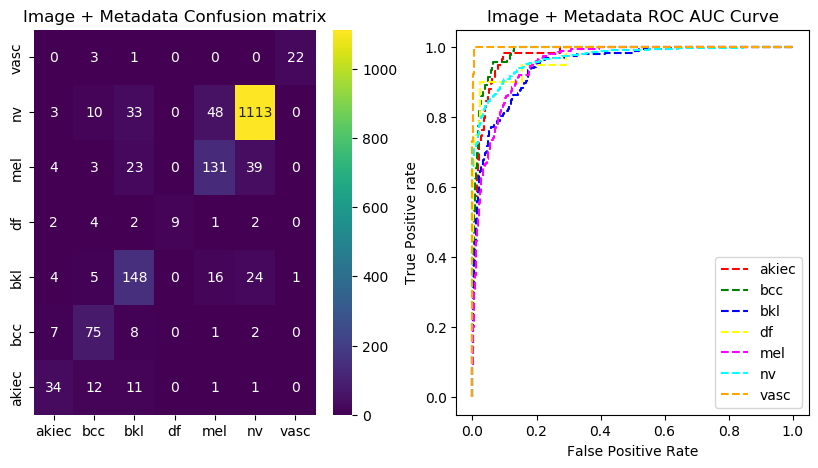

In [46]:
#training Image + Metadata (Concatenation) model
#split image and metadata features into train and test
data = np.load("model/ham_data.npy", allow_pickle=True)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = data

#defining image model
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenating both models
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classification
meta_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
#compiling, training and loading model
meta_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/meta_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/meta_weights.hdf5', verbose = 1, save_best_only = True)
    hist = meta_model.fit([X_img_train, X_meta_train], y_trains,batch_size = 32, epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/meta_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    meta_model.load_weights("model/meta_weights.hdf5")
#perform prediction on test data
prob = meta_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image + Metadata", y_test1, predict, prob)

Attention-Multimodal Fusion Accuracy  : 0.93
Attention-Multimodal Fusion AUC       : 0.9933352258599969
              precision    recall  f1-score   support

       akiec       0.87      0.76      0.81        59
         bcc       0.88      0.90      0.89        93
         bkl       0.94      0.80      0.86       198
          df       0.95      0.90      0.92        20
         mel       0.74      0.88      0.80       200
          nv       0.97      0.96      0.97      1207
        vasc       0.96      1.00      0.98        26

    accuracy                           0.93      1803
   macro avg       0.90      0.89      0.89      1803
weighted avg       0.93      0.93      0.93      1803



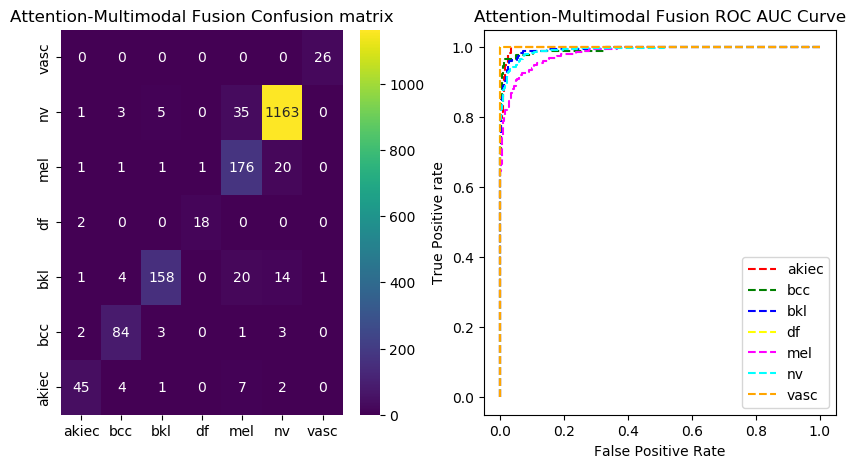

In [47]:
#Attention-based multimodal fusion
#defining image model with attention layer
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    RepeatVector(2),
    attention(return_sequences=True,name='imgattention'),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model with attention layer
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    RepeatVector(2),
    attention(return_sequences=True,name='metaattention'),
    Flatten(),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenate image and metadata model with attention layer
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classifictaion
attention_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
attention_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
#compiling, training and loading model
if os.path.exists("model/attention_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/attention_weights.hdf5', verbose = 1, save_best_only = True)
    hist = attention_model.fit([X_img_train, X_meta_train], y_trains,batch_size = 32, epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/attention_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    attention_model.load_weights("model/attention_weights.hdf5")
#perform prediction on test data
prob = attention_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Attention-Multimodal Fusion", y_test1, predict, prob)